In [15]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Problem 3

In [51]:
N = 10**4
def reject(l, c, N):
    accepted = []
    attempts = 0
    start = time.perf_counter()

    while len(accepted) < N:
        u_1 = np.random.uniform()
        u_2 = np.random.uniform()
        X = -np.log(1 - u_1) / l

        accept_p = ( X / l ) * np.exp(-(1 - l) * X) / c

        attempts += 1

        if u_2 < accept_p:
            accepted.append(X)

    timed = time.perf_counter() - start

    acceptance = N / attempts
    time_per_a = timed / N
    return np.array(accepted) , acceptance, time_per_a

In [95]:
def plot_all(l, c, N):
    accepted, acceptance_rate, time_per_a = reject(l, c, N)

    print("lambda =", l)
    print("c =", c)
    print("theoretical acceptance =", 1/c)
    print("empirical acceptance =", acceptance_rate)
    print("mean time per accepted sample =", time_per_a)

    bins = np.linspace(0,15,50)
    width = bins[1] - bins[0]

    plt.figure()
    plt.hist(accepted, bins=bins, density=True, color = 'pink', edgecolor='black')

    x = np.linspace(0, 15, 500)
    f = x * np.exp(-x)

    plt.figure()
    plt.plot(x, f, linewidth=2, color = 'purple')

    plt.xlabel("x")
    plt.ylabel("Density")
    plt.title(f"Rejection Sampling: λ = {l}")

    print("Bin width =", width)
    plt.show()
    return 

lambda = 0.5
c = 1.4715177646857693
theoretical acceptance = 0.6795704571147613
empirical acceptance = 0.6831067695880866
mean time per accepted sample = 8.682404202409088e-06
Bin width = 0.30612244897959184


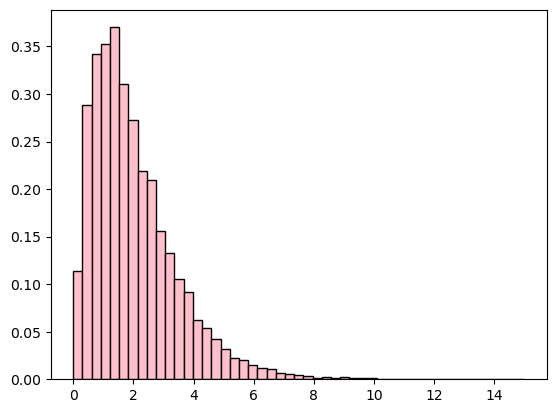

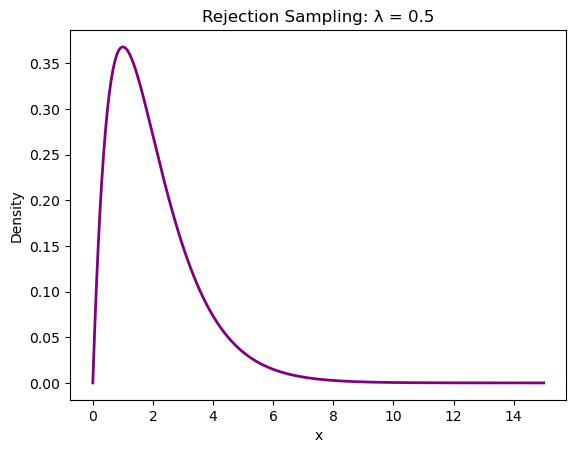

In [97]:
l = 0.5
c = 4 / np.e
N = 10 ** 4

plot_all(l, c, N)

lambda = 0.2
c = 2.2992465073215143
theoretical acceptance = 0.4349250925534473
empirical acceptance = 0.4339712711018531
mean time per accepted sample = 1.2080925001646391e-05
Bin width = 0.30612244897959184


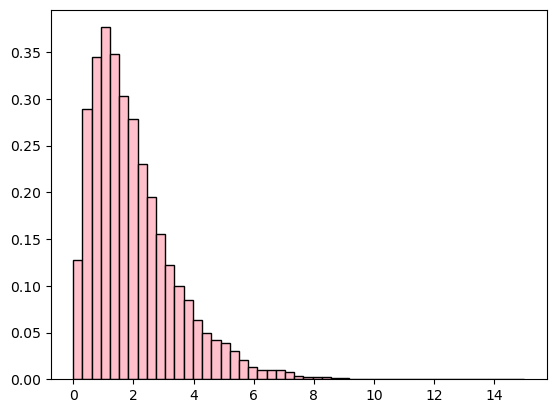

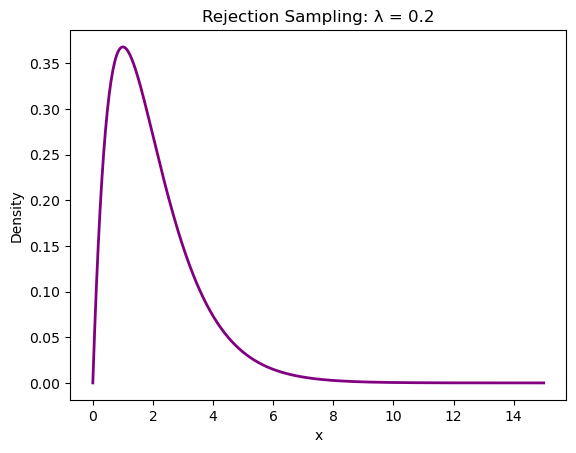

In [99]:
l = 0.2
c = 1 / ( 0.16 * np.e )
N = 10 ** 4

plot_all(l, c, N)

# Problem 4

In [111]:
N = 10 ** 5
a = 0.9
l_f = 1000
l_s = 10

B = np.random.uniform(size = N) < a

l = np.where(B, l_f, l_s)

U = np.random.uniform(size = N)
T = -np.log(U) / l

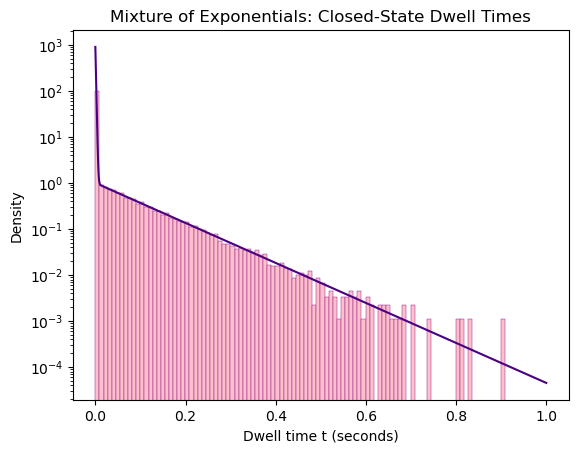

In [117]:
plt.hist(T, bins = 100, density = True, color = 'pink', edgecolor = 'purple', linewidth = 0.3)

t = np.linspace(0, 1.0, 1000)
f = (a * l_f * np.exp(- l_f * t) + (1-a) * l_s * np.exp(-l_s * t))

plt.plot(t, f, color = 'indigo')

plt.yscale("log")

plt.xlabel("Dwell time t (seconds)")
plt.ylabel("Density")
plt.title("Mixture of Exponentials: Closed-State Dwell Times")

plt.show()

In [119]:
emp_mean = np.mean(T)
theory_mean = a/l_f + (1-a)/l_s

emp_prob = np.mean(T > 0.05)
theory_prob = (a * np.exp(-lambda_f * 0.05)
               + (1-a) * np.exp(-lambda_s * 0.05))

print("Empirical mean =", emp_mean)
print("Theoretical mean =", theory_mean)

print("Empirical P(T > 50 ms) =", emp_prob)
print("Theoretical P(T > 50 ms) =", theory_prob)

Empirical mean = 0.010777045542597622
Theoretical mean = 0.010899999999999998
Empirical P(T > 50 ms) = 0.06033
Theoretical P(T > 50 ms) = 0.060653065971263326


# Problem 5 

Empirical mean = 0.33958109999999997
Theoretical mean = 0.3333333333333333
Empirical SD / mean = 0.6829073982869756
Theoretical SD / mean = 0.7071067811865475
Smallest core = 1
Largest core = 9292


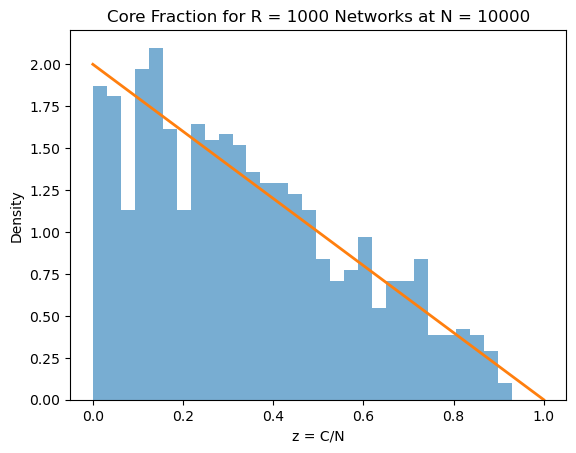

In [122]:
N = 10**4
R = 10**3

# C(3) = 1 for all R realizations
C = np.ones(R, dtype=int)

# Growth process
for n in range(3, N):
    
    # Probability that each realization gains a core node
    p = C / n
    
    # One vector of R Bernoulli draws
    grow = np.random.uniform(size=R) < p
    
    # Update all R realizations simultaneously
    C += grow

# Final core fraction
z = C / N

# Empirical statistics
empirical_mean = np.mean(z)
empirical_sd = np.std(z)
empirical_ratio = empirical_sd / empirical_mean

print("Empirical mean =", empirical_mean)
print("Theoretical mean =", 1/3)

print("Empirical SD / mean =", empirical_ratio)
print("Theoretical SD / mean =", 1/np.sqrt(2))

print("Smallest core =", np.min(C))
print("Largest core =", np.max(C))

# Histogram
plt.figure()

plt.hist(z, bins=30, density=True, alpha=0.6)

x = np.linspace(0, 1, 500)
h = 2 * (1 - x)

plt.plot(x, h, linewidth=2)

plt.xlabel("z = C/N")
plt.ylabel("Density")
plt.title("Core Fraction for R = 1000 Networks at N = 10000")

plt.show()